# 06 — Topology gallery

`conninfpy.topologies` ships a registry of named synthetic effect
patterns. This notebook visualizes every registered scenario so you
can pick one that matches the kind of effect you expect in your
data — or use the gallery to stress-test a method across regimes.

Each scenario produces an `effect_mask` (ground truth) and realistic
connectivity matrices under a modular covariance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import (
    TopologyDatasetGenerator,
    list_scenarios,
    get_scenario,
)

names = list_scenarios()
print(f"{len(names)} scenarios:")
for n in names:
    print(f"  - {n}")

19 scenarios:
  - within_module_dense
  - between_modules_dense
  - hub
  - chain
  - fragmented_within_module
  - multi_cluster_within_module
  - checkerboard_within_module
  - scattered_cross_block
  - uniform_base_modular_effect
  - within_plus_between
  - perfect_matching_within_module
  - cross_block_connected_chain
  - rich_club
  - two_equal_disconnected_cliques
  - focal_clique_inside_module
  - partial_bipartite_between_modules
  - gradient_effect_chain
  - gradient_core_periphery_within_module
  - imbalanced_modules_within_effect


## 1. Generate a mask per scenario

We reuse the same generator (60 nodes × 4 modules) so differences
come from the topology alone.

In [2]:
gen = TopologyDatasetGenerator(n_nodes=60, n_modules=4, seed=0)
datasets = {
    name: gen.generate(name, effect_size=0.3, n_samples=10, time_points=30)
    for name in names
}

## 2. Mask gallery

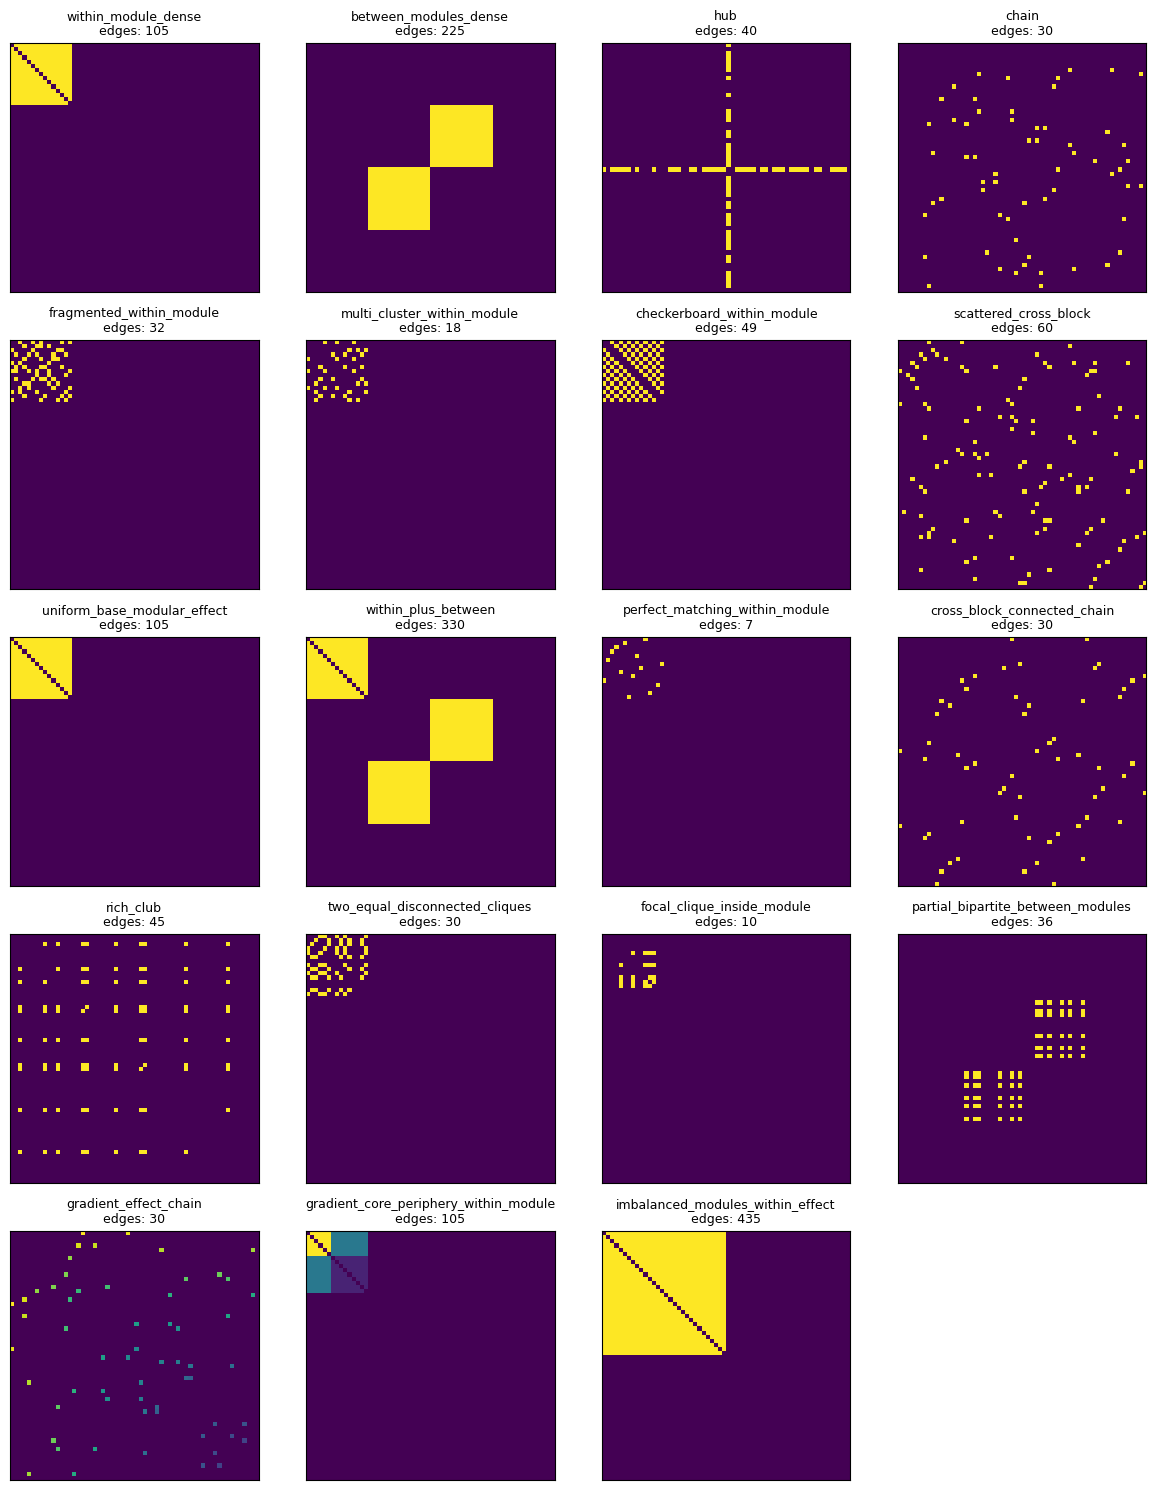

In [3]:
n_cols = 4
n_rows = int(np.ceil(len(names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
for ax, name in zip(axes.flat, names):
    ds = datasets[name]
    im = ax.imshow(ds.effect_mask, cmap="viridis", aspect="equal")
    n_edges = int((ds.effect_mask != 0).sum() // 2)
    ax.set_title(f"{name}\nedges: {n_edges}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[len(names):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. A scenario ↔ a recommended method

Rule of thumb — which enhancement is most likely to do best:

| Topology family | Favoured method(s) |
|---|---|
| `within_module_dense`, `uniform_base_modular_effect`, `imbalanced_modules_within_effect` | **cNBS**, **FBC-TFNBS** — block-aligned |
| `between_modules_dense`, `partial_bipartite_between_modules` | **cNBS** (single off-diagonal block) |
| `hub`, `rich_club` | **TFNBS** — no block alignment |
| `chain`, `cross_block_connected_chain`, `gradient_effect_chain` | **TFNBS** |
| `fragmented_within_module`, `perfect_matching_within_module`, `multi_cluster_within_module`, `scattered_cross_block` | **raw t-stat + BH-FDR** (no connected structure to enhance) |
| `gradient_core_periphery_within_module`, `checkerboard_within_module` | **TFNBS** (threshold-free best) |

Scenarios 01-04 used a couple of these; the others are mostly useful
when you want to stress-test a method against a specific failure
mode.

## 4. Customising a scenario

Every scenario accepts parameter overrides via `scenario_params=` —
for instance, to change the hub location or the chain length.

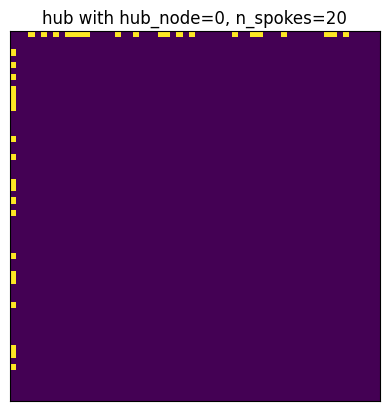

In [4]:
ds_custom = gen.generate(
    "hub",
    effect_size=0.3, n_samples=5, time_points=30,
    scenario_params={"hub_node": 0, "n_spokes": 20},
)
plt.imshow(ds_custom.effect_mask, cmap="viridis")
plt.title("hub with hub_node=0, n_spokes=20")
plt.xticks([]); plt.yticks([])
plt.show()